# Praca domowa III - sieci neuronowe
## GRUPA B - sieć CNN
Celem projektu jest implementacja konwolucyjnej sieci neuronowej (CNN) służącej do klasyfikacji obrazów z popularnego zbioru CIFAR-10. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from matplotlib import cm

## 1. Wstęna analiza danych
Zbiór składa się z 60 000 kolorowych (3 kanały RGB) obrazów w rozdzielczości 32x32 pikseli, podzielonych na 10 równo podzielonych klas (m.in. pojazdy i zwierzęta). Wartości pikseli zawierają się w przedziale od 0 do 255

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# RAW DATASET

raw_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True)
raw_test_dataset = datasets.CIFAR10(root='./data', train=False, download=True)

classes = ['plain', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

sample_image, sample_label = raw_train_dataset[0]

print("--- STATYSTYKI ZBIORU CIFAR-10 (PRZED TRANSFORMACJĄ) ---")
raw_img, _ = raw_train_dataset[0]
raw_img_np = np.array(raw_img) 
print(f"Typ danych: {type(raw_img)}")
print(f"Wymiary pojedynczego obrazka (Kanały, Wysokość (px), Szerokość (px)): {raw_img_np.shape}")
print(f"Minimalna wartość piksela: {raw_img_np.min()}")
print(f"Maksymalna wartość piksela: {raw_img_np.max()}")
all_targets = raw_train_dataset.targets + raw_test_dataset.targets
class_counts = {cls: all_targets.count(i) for i, cls in enumerate(classes)}
print("Liczba obrazków w każdej klasie:")
for cls, count in class_counts.items():
    print(f"  {cls}: {count}")

Using device: cuda
Files already downloaded and verified


c:\Coding\Uni\sem_II\PMiNA\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
--- STATYSTYKI ZBIORU CIFAR-10 (PRZED TRANSFORMACJĄ) ---
Typ danych: <class 'PIL.Image.Image'>
Wymiary pojedynczego obrazka (Kanały, Wysokość (px), Szerokość (px)): (32, 32, 3)
Minimalna wartość piksela: 0
Maksymalna wartość piksela: 255
Liczba obrazków w każdej klasie:
  plain: 6000
  car: 6000
  bird: 6000
  cat: 6000
  deer: 6000
  dog: 6000
  frog: 6000
  horse: 6000
  ship: 6000
  truck: 6000


### Przykładowe obrazy

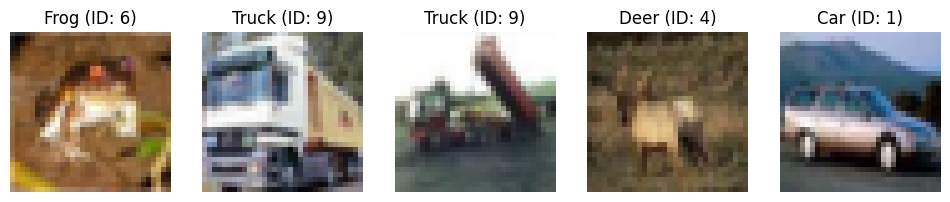

In [3]:
plt.figure(figsize=(12, 3))
for i in range(5):
    img, label = raw_train_dataset[i]
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f"{classes[label].capitalize()} (ID: {label})")
    plt.axis('off')
plt.show()

## 2. Przygotowanie danych oraz statystyki
Aby sieć neuronowa mogła uczyć się w sposób optymalny i stabilny, surowe obrazy (w formacie PIL i zakresie wartości pikseli 0-255) musiały zostać poddane transformacjom:
1. **`ToTensor()`**: Konwertuje obrazy na tensory PyTorch oraz skaluje wartości do przedziału 0-1. Dodatkowo zmienia układ wymiarów z `[H, W, C]` na wymagany przez bibliotekę układ `[C, H, W]`.
2. **`Normalize()`**: Zastosowano standaryzację (Z-score) dla każdego z trzech kanałów RGB (Czerwony, Zielony, Niebieski). Zamiast uniwersalnych wartości `(0.5, 0.5, 0.5)`, użyto wcześniej już precyzyjnie wyliczonych statystyk dedykowanych dla zbioru CIFAR-10:
   - Średnia: `(0.4914, 0.4822, 0.4465)`
   - Odchylenie standardowe: `(0.2470, 0.2435, 0.2616)`

Po nałożeniu normalizacji, wartości pikseli zostaną wycentrowane wokół zera. Dzięki temu algorytm optymalizacyjny szybciej znajdzie najniższy punkt, a gradienty podczas treningu nie będą eksplodować (zbyt duże liczby). 

Wykorzystane zostały również DataLoadery z odpowiednimi parametrami:
- **`batch_size`**: ilość obrazów, którą sieć analizuje na raz
- **`shuffle`**: wartość binarna, która określa czy przed każdym ponownym przejściem przez zbiór obrazy powinny być tasowane

In [4]:
# TRANSFORMED DATASET

def dataloaders(batch_size=64):
    transform = transforms.Compose(
        [transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))]
    )

    train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_dataset, test_dataset, train_loader, test_loader

# Przykład
train_dataset, test_dataset, train_loader, test_loader = dataloaders()
sample_image, sample_label = train_dataset[0]

print("--- STATYSTYKI ZBIORU CIFAR-10 (PO TRANSFORMACJI) ---")
print(f"Liczba próbek treningowych: {len(train_dataset)}")
print(f"Liczba próbek testowych: {len(test_dataset)}")
print(f"Wymiary pojedynczego obrazka (Kanały, Wysokość (px), Szerokość (px)): {sample_image.shape}")
print(f"Minimalna wartość piksela: {sample_image.min().item()}")
print(f"Maksymalna wartość piksela: {sample_image.max().item()}")

Files already downloaded and verified
Files already downloaded and verified
--- STATYSTYKI ZBIORU CIFAR-10 (PO TRANSFORMACJI) ---
Liczba próbek treningowych: 50000
Liczba próbek testowych: 10000
Wymiary pojedynczego obrazka (Kanały, Wysokość (px), Szerokość (px)): torch.Size([3, 32, 32])
Minimalna wartość piksela: -1.9894737005233765
Maksymalna wartość piksela: 2.094278573989868


### Przykładowe obrazy po transofrmacji

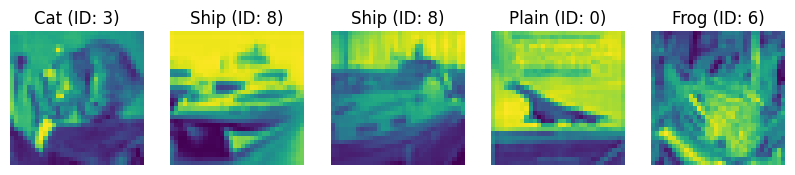

In [5]:
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(example_data[i][0])
    plt.title(f"{classes[example_targets[i]].capitalize()} (ID: {example_targets[i]})")
    plt.axis('off')
plt.show()

## 3. Architektura sieci konwolucyjnej

Klasa `ConvNet` przyjmuje odpowiednie parametry: `kernel_size` oraz `pool_type`. 

* **Warstwy Konwolucyjne (`nn.Conv2d`):** Służą do wykrywania lokalnych wzorców na obrazie (krawędzi, tekstur, a w głębszych warstwach całych obiektów). 
  * Pierwsza warstwa (`conv1`) pobiera obraz z 3 kanałami kolorów (RGB) i rozszerza go do 16 map cech. 
  * Druga warstwa (`conv2`) bierze te 16 map i szuka w nich bardziej złożonych zależności, tworząc 32 mapy cech.
  * Zastosowano dynamiczny padding (`kernel_size // 2`), który gwarantuje, że niezależnie od wybranego rozmiaru filtra (np. 3x3, 5x5), wymiary przestrzenne (szerokość i wysokość) obrazka po przejściu przez konwolucję pozostaną niezmienione.

* **Funkcja Aktywacji (`torch.relu`):** Zastosowana w metodzie `forward` nieliniowa funkcja aktywacji (Rectified Linear Unit). Zamienia ona wszystkie wartości ujemne z map cech na zera, a dodatnie pozostawia bez zmian.

* **Warstwy łączące / Pooling (`nn.MaxPool2d` / `nn.AvgPool2d` / `nn.Identity`):**
  Zależnie od wybranego parametru eksperymentu, warstwa ta agreguje informacje z sąsiadujących pikseli (okno 2x2). 
  * `MaxPool` wybiera najsilniejszą cechę z okienka (najwyższą wartość aktywacji).
  * `AvgPool` uśrednia wartości z okienka.
  Obie te operacje zmniejszają rozdzielczość obrazka dokładnie o połowę (z 32x32 na 16x16, a potem na 8x8), co drastycznie redukuje liczbę parametrów w sieci i chroni ją przed przeuczeniem (overfittingiem). W przypadku wyboru `none` (Identity), wymiary obrazu pozostają nienaruszone (32x32).

* **Spłaszczanie (`torch.flatten`):**
  Przekształca trójwymiarowy tensor wyjściowy z ostatnich warstw konwolucyjnych w jeden długi, jednowymiarowy wektor. Wymiar tego wektora (`feature_size`) jest dynamicznie liczony w konstruktorze w zależności od tego, czy użyto poolingu (32 kanały * 8 * 8 = 2048), czy nie (32 kanały * 32 * 32 = 32768).

* **Warstwy w pełni połączone (`nn.Linear`):**
  Pełnią rolę ostatecznego klasyfikatora. Pierwsza z nich (`fc1`) mapuje wyciągnięte cechy wizualne na wektor 128 ukrytych neuronów. Druga (`fc2`) stanowi warstwę wyjściową sieci — redukuje dane do 10 neuronów, gdzie każdy neuron odpowiada jednej klasie z zestawu CIFAR-10 (np. kot, pies, samolot).

In [6]:
class ConvNet(nn.Module):
    def __init__(self, kernel_size=3, pool_type="max"):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=kernel_size, padding=kernel_size//2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=kernel_size, padding=kernel_size//2)

        if pool_type == "max":
            self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
            self.feature_size = 32 * 8 * 8
        elif pool_type == "avg":
            self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
            self.feature_size = 32 * 8 * 8
        elif pool_type == "none":
            self.pool = nn.Identity()
            self.feature_size = 32 * 32 * 32
        else:
            raise ValueError(f"Nieznany typ pooling: {pool_type}")
        
        self.fc1 = nn.Linear(self.feature_size, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## 4. Trening sieci i walidacja

Funkcja `train_model` składa się z powtarzających się cykli (epok). Jedna epoka to jeden pełny "przegląd" całego zbioru danych.

**1. Przygotowanie:**
* Tworzymy słownik `history`, do którego po każdej epoce będziemy wrzucać wyniki (błędy i skuteczność)

**2. Treningu:**
* Pętla `for inputs, labels in train_loader`: Bierzemy nasze dane paczkami (batchami)

Wewnątrz tej pętli :
1. `optimizer.zero_grad()`: Czyścimy pamięć z poprzedniej paczki
2. `outputs = model(inputs)`: **Forward pass.** Model patrzy na obrazki i zgaduje, co na nich jest
3. `loss = criterion(...)`: Obliczamy błąd. Porównujemy odpowiedzi modelu z rzeczywistymi etykietami
4. `loss.backward()`: **Backpropagation.**
5. `optimizer.step()`: **Aktualizacja wag.** Optymalizator poprawia parametry sieci na podstawie obliczonych błędów, żeby przy następnym obrazku model pomylił się odrobinę mniej

**3. Statystyki:**
Na bieżąco sumujemy błędy (`running_loss`) i zliczamy, ile obrazków model zgadł poprawnie (`correct_train`). Funkcja `torch.max` wybiera klasę dla której model był najbardziej pewny

**4. Walidacja**
* Przepuszczamy dane testowe `test_loader` przez model, zliczamy błędy i poprawne odpowiedzi

**5. Podsumowanie:**
Na koniec dzielimy zebrane sumy przez liczbę wszystkich obrazków (żeby mieć np. procentowe Accuracy) i dopisujemy je do słownika `history`. Tak kończy się epoka i pętla przechodzi do następnej 

Wyniki z każdej epoki są wypisywane w terminalu, aby móc widzieć zachodzące zmiany

In [7]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device):
    model.to(device)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = correct_train / total_train

        model.eval()
        running_test_loss = 0.0
        correct_test = 0
        total_test = 0
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
        
        epoch_test_loss = running_test_loss / len(test_loader)
        epoch_test_acc = correct_test / total_test

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_loss'].append(epoch_test_loss)
        history['test_acc'].append(epoch_test_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} "
              f"Test Loss: {epoch_test_loss:.4f}, Test Acc: {epoch_test_acc:.4f}")
        
    return history

## 5. EKSPERYMENTY
Funckja pomocnicza `run_experiment` stworzona w celu sprawnego przeprowadzenia serii badań. Przyjmuje parametr config - słownik konfiguracyjny na podstawie, którego tworzony jest model i cały cykl jego nauki

**Kroki realizowane przez funkcję:**
1. **Dynamiczne ładowanie danych:** Wywołuje zdefiniowaną wcześniej funkcję `dataloaders`, przekazując do niej rozmiar paczki (`batch_size`) specyficzny dla danego eksperymentu
2. **Inicjalizacja architektury:** Tworzy nowy, "czysty" obiekt sieci `ConvNet`, dopasowując rozmiar filtra (`kernel_size`) oraz rodzaj poolingu (`pool_type`) zgodnie z konfiguracją. Gwarantuje to, że każdy eksperyment startuje z losowymi wagami bazowymi i nie jest obciążony wiedzą z poprzednich testów
3. **Konfiguracja optymalizatora:** Definiuje funkcję straty (`CrossEntropyLoss`) oraz inicjalizuje optymalizator `Adam`, przekazując mu zadany współczynnik uczenia (`learning_rate`)
4. **Uruchomienie:** Wywołuje główną pętlę uczącą na ustalony czas 10 epok
5. **Wyniki:** Zwraca słownik `history` zawierający szczegółowe statystyki z każdej epoki, co pozwala na późniejszą wizualizację i porównanie wyników

Dzięki temu wszystkiemu przeprowadzenie dowolnej serii testów sprowadza się do uruchomienia funkcji z odpowiednim parametrem. (Eksperymenty mogą być wykonywane tylko na odpowiednich wartościach ze słownika: kernel_size, pool_type, batch_size, learning_rate) Podczas serii zmieniany jest tylko jeden hiperparametr (reszta jest ustalona)

In [8]:
def run_experiment(config):
    print('=' * 50)
    print(f"Eksperyment: {config['name']}")
    print('=' * 50)

    _, _, train_loader, test_loader = dataloaders(config['batch_size'])

    model = ConvNet(kernel_size=config['kernel_size'], pool_type=config['pool_type'])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    history = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=10, device=device)
    
    return history

## SERIA I: wpływ learning_rate
Testowane wartości: [0.0001, 0.001, 0.01, 0.1]

In [9]:
results_lr = {}
lr_values = [0.0001, 0.001, 0.01, 0.1]

for lr in lr_values:
    config = {
        'name': f"Learning Rate: {lr}",
        'kernel_size': 3,
        'pool_type': 'max',
        'batch_size': 64,
        'learning_rate': lr
    }
    history = run_experiment(config)
    results_lr[lr] = history

Eksperyment: Learning Rate: 0.0001
Files already downloaded and verified
Files already downloaded and verified
Epoch [1/10] Train Loss: 1.7528, Train Acc: 0.3800 Test Loss: 1.5229, Test Acc: 0.4660
Epoch [2/10] Train Loss: 1.4462, Train Acc: 0.4887 Test Loss: 1.3791, Test Acc: 0.5116
Epoch [3/10] Train Loss: 1.3303, Train Acc: 0.5329 Test Loss: 1.3040, Test Acc: 0.5373
Epoch [4/10] Train Loss: 1.2572, Train Acc: 0.5591 Test Loss: 1.2394, Test Acc: 0.5613
Epoch [5/10] Train Loss: 1.1983, Train Acc: 0.5820 Test Loss: 1.2057, Test Acc: 0.5707
Epoch [6/10] Train Loss: 1.1528, Train Acc: 0.5990 Test Loss: 1.1512, Test Acc: 0.5961
Epoch [7/10] Train Loss: 1.1113, Train Acc: 0.6150 Test Loss: 1.1176, Test Acc: 0.6054
Epoch [8/10] Train Loss: 1.0758, Train Acc: 0.6276 Test Loss: 1.0942, Test Acc: 0.6156
Epoch [9/10] Train Loss: 1.0449, Train Acc: 0.6378 Test Loss: 1.0856, Test Acc: 0.6133
Epoch [10/10] Train Loss: 1.0171, Train Acc: 0.6461 Test Loss: 1.0816, Test Acc: 0.6228
Eksperyment: Learn

### WIZUALIZACJA SERII I

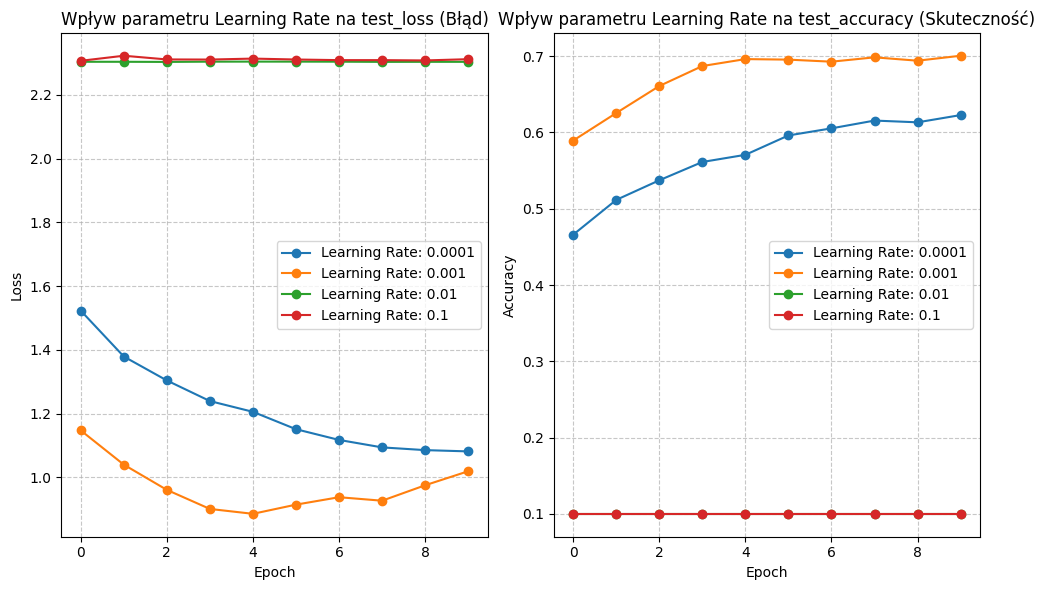

,Final Test Loss,Final Test Accuracy,Best Test Accuracy
Learning Rate,,,
0.0001,1.081632,0.6228,0.6228
0.0010,1.019399,0.7006,0.7006
0.0100,2.303145,0.1000,0.1000
0.1000,2.311453,0.1000,0.1000


In [10]:
from visualization import plot_experiment_series_reults, generate_results_table

plot_experiment_series_reults(results_lr, 'Learning Rate')
generate_results_table(results_lr, 'Learning Rate')

### Wnioski z Serii I: learning_rate

Przeprowadzony eksperyment ewidentnie dowodzi, że współczynnik uczenia (`lr`) jest najbardziej krytycznym hiperparametrem w procesie trenowania sieci. Dobór tej wartości drastycznie zmienił zachowanie optymalizatora (Adam), co widać na wykresie Test Accuracy:

1. **`LR = 0.1` (Zbyt wysoki - czerwona linia):** Skuteczność modelu oscyluje wokół 10% przez cały czas trwania treningu. Biorąc pod uwagę, że zbiór CIFAR-10 składa się z 10 klas, wynik 10% oznacza, że sieć nie uczy się wcale i dokonuje losowego zgadywania
2. **`LR = 0.01` (Niestabilny - zielona linia):** Model uczy się minimalnie (osiągając ok. 40-45%), ale krzywa uczenia jest bardzo "poszarpana"
3. **`LR = 0.001` (Optymalny - pomarańczowa linia):** Zdecydowanie najlepsza konfiguracja. Krzywa uczenia rośnie stromo i bardzo stabilnie, osiągając najwyższe "Best Accuracy" (prawie 70%) w okolicach 7-8 epoki, po czym delikatnie zwalnia, sygnalizując rozpoczęcie fazy przeuczenia (overfittingu). Wartość ta stanowi idealny balans między szybkością a precyzją uczenia.
4. **`LR = 0.0001` (Zbyt niski - niebieska linia):** Proces uczenia jest niezwykle gładki i stabilny (pozbawiony szumu), ale zachodzi bardzo powoli. Po 10 epokach sieć wciąż nie osiągnęła swojego pełnego potencjału i wciąż się uczy. Osiągnięcie wyników podobnych do optymalnego LR wymagałoby znacznego wydłużenia czasu treningu (zwiększenia liczby epok).

## SERIA II: wpływ batch_size
Testowane wartości: [16, 32, 64, 128]

In [11]:
results_batch_size = {}
batch_sizes = [16, 32, 64, 128]

for batch_size in batch_sizes:
    config = {
        'name': f"Batch Size: {batch_size}",
        'kernel_size': 3,
        'pool_type': 'max',
        'learning_rate': 0.001,
        'batch_size': batch_size
    }
    history = run_experiment(config)
    results_batch_size[batch_size] = history

Eksperyment: Batch Size: 16
Files already downloaded and verified


c:\Coding\Uni\sem_II\PMiNA\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Epoch [1/10] Train Loss: 1.2810, Train Acc: 0.5376 Test Loss: 1.0385, Test Acc: 0.6286
Epoch [2/10] Train Loss: 0.9465, Train Acc: 0.6672 Test Loss: 0.9374, Test Acc: 0.6715
Epoch [3/10] Train Loss: 0.8146, Train Acc: 0.7118 Test Loss: 0.9193, Test Acc: 0.6773
Epoch [4/10] Train Loss: 0.7172, Train Acc: 0.7473 Test Loss: 0.8967, Test Acc: 0.6933
Epoch [5/10] Train Loss: 0.6376, Train Acc: 0.7746 Test Loss: 0.9002, Test Acc: 0.6973
Epoch [6/10] Train Loss: 0.5618, Train Acc: 0.8010 Test Loss: 0.9603, Test Acc: 0.6986
Epoch [7/10] Train Loss: 0.4995, Train Acc: 0.8218 Test Loss: 0.9926, Test Acc: 0.6960
Epoch [8/10] Train Loss: 0.4383, Train Acc: 0.8436 Test Loss: 1.0860, Test Acc: 0.6871
Epoch [9/10] Train Loss: 0.3859, Train Acc: 0.8621 Test Loss: 1.1687, Test Acc: 0.6861
Epoch [10/10] Train Loss: 0.3342, Train Acc: 0.8797 Test Loss: 1.2580, Test Acc: 0.6799
Eksperyment: Batch Size: 32
Files already downloaded and verified
Files already downloaded 

### WIZUALIZACJA SERII II

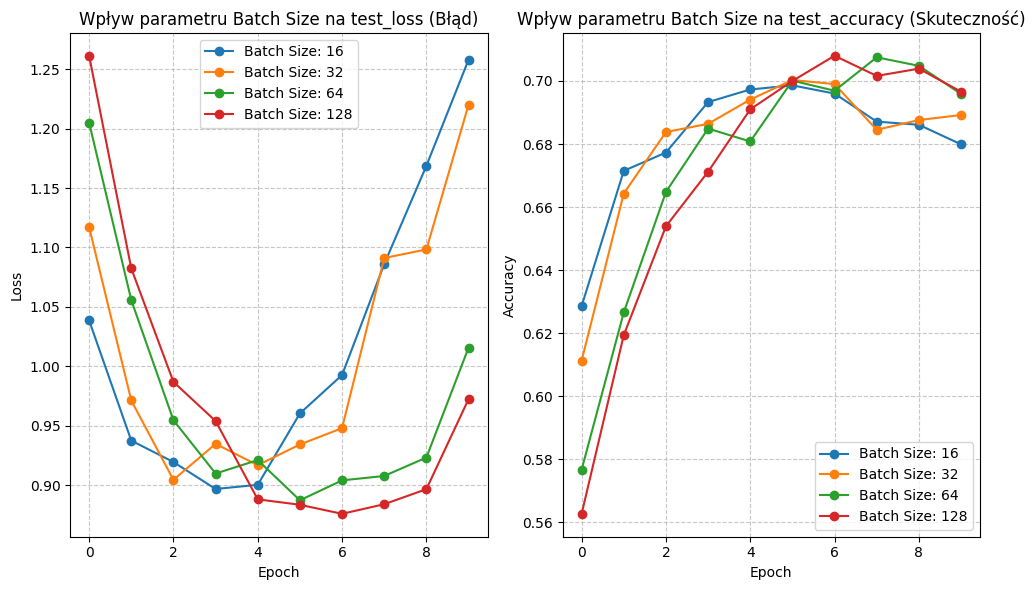

,Final Test Loss,Final Test Accuracy,Best Test Accuracy
Batch Size,,,
16,1.257977,0.6799,0.6986
32,1.220047,0.6892,0.7003
64,1.015558,0.6959,0.7075
128,0.972251,0.6966,0.7080


In [12]:
plot_experiment_series_reults(results_batch_size, 'Batch Size')
generate_results_table(results_batch_size, 'Batch Size')

### Wnioski z Serii II: batch_size

Powyższy wykres `Test Loss` wskazuje, że rozmiar paczki danych ma kluczowy wpływ na stabilność procesu uczenia oraz idealnie pokazuje proces `overfittingu`

1. **Małe paczki (`Batch Size = 16` i `32`):** Krzywe (szczególnie niebieska) opadają najbardziej stromo w początkowej fazie. Oznacza to, że model uczy się bardzo szybko, ponieważ wagi aktualizowane są znacznie częściej. Niestety, tak mała paczka wprowadza duży "szum" informacyjny. Skutkuje to najwcześniejszym (ok. 3. epoki) i najbardziej gwałtownym przeuczeniem – błąd dla paczki 16 na koniec treningu wystrzeliwuje najwyżej ze wszystkich.
2. **Duża paczka (`Batch Size = 128`):** Czerwona krzywa zachowuje się zupełnie inaczej – jest najgładsza, a jej spadek jest najmniej stromy. Wynika to z faktu, że uśrednianie błędu ze 128 obrazków na raz daje optymalizatorowi bardzo precyzyjny i uśredniony "kierunek" zmian. Dzięki temu model jest znacznie bardziej odporny na szum, a efekt overfittingu jest wyraźnie opóźniony i złagodzony.
3. **Złoty środek (`Batch Size = 64`):** Stanowi optymalny kompromis pomiędzy szybkością a odpornością na przeuczenie. 

**Podsumowanie:** Choć we wszystkich wariantach po 4-5 epoce wystąpiło zjawisko nadmiernego dopasowania do danych treningowych, eksperyment dowodzi, że w przypadku tej konkretnej architektury większe wartości Batch Size (64 lub 128) działają jako forma ukrytej regularyzacji, stabilizując proces optymalizacji.

## SERIA III: wpływ kernel_size
Testowane wartości: [3, 5, 7]

In [13]:
results_kernel = {}
kernel_values = [3, 5, 7]

for k in kernel_values:
    config = {
        'name': f'Kernel Size {k}x{k}',
        'kernel_size': k,
        'pool_type': 'max',
        'learning_rate': 0.001,
        'batch_size': 64
    }
    results_kernel[k] = run_experiment(config)

Eksperyment: Kernel Size 3x3
Files already downloaded and verified


c:\Coding\Uni\sem_II\PMiNA\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Epoch [1/10] Train Loss: 1.3780, Train Acc: 0.5107 Test Loss: 1.1287, Test Acc: 0.6043
Epoch [2/10] Train Loss: 1.0439, Train Acc: 0.6345 Test Loss: 1.0072, Test Acc: 0.6516
Epoch [3/10] Train Loss: 0.8950, Train Acc: 0.6863 Test Loss: 0.9497, Test Acc: 0.6699
Epoch [4/10] Train Loss: 0.7953, Train Acc: 0.7218 Test Loss: 0.8852, Test Acc: 0.6952
Epoch [5/10] Train Loss: 0.7118, Train Acc: 0.7491 Test Loss: 0.9055, Test Acc: 0.6904
Epoch [6/10] Train Loss: 0.6352, Train Acc: 0.7756 Test Loss: 0.8677, Test Acc: 0.7064
Epoch [7/10] Train Loss: 0.5628, Train Acc: 0.8036 Test Loss: 0.9214, Test Acc: 0.7034
Epoch [8/10] Train Loss: 0.5008, Train Acc: 0.8251 Test Loss: 0.9531, Test Acc: 0.7044
Epoch [9/10] Train Loss: 0.4416, Train Acc: 0.8443 Test Loss: 0.9929, Test Acc: 0.6966
Epoch [10/10] Train Loss: 0.3865, Train Acc: 0.8625 Test Loss: 1.0411, Test Acc: 0.6977
Eksperyment: Kernel Size 5x5
Files already downloaded and verified
Files already downloaded

### WIZUALIZACJA SERII III

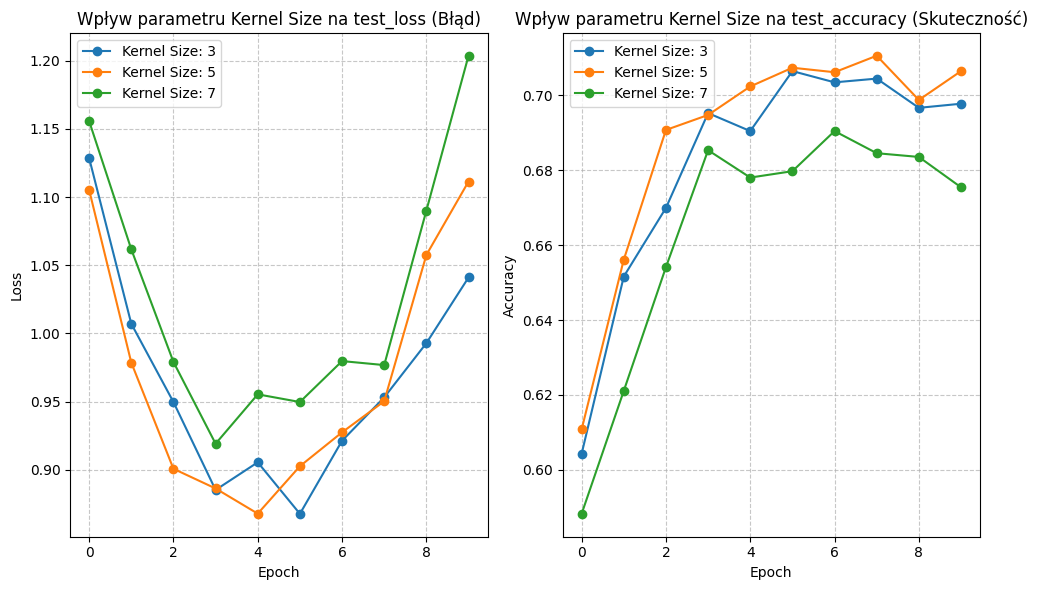

,Final Test Loss,Final Test Accuracy,Best Test Accuracy
Kernel Size,,,
3,1.041077,0.6977,0.7064
5,1.111474,0.7064,0.7105
7,1.203732,0.6754,0.6904


In [14]:


plot_experiment_series_reults(results_kernel, 'Kernel Size')
generate_results_table(results_kernel, 'Kernel Size')

### Wnioski z Serii III: kernel_size

Analiza wykresów dla parametru `kernel_size` wyraźnie pokazuje, że w przypadku analizy obrazów o bardzo niskiej rozdzielczości (takich jak 32x32 piksele w CIFAR-10) wielkość okna ma ogromne znaczenie dla skuteczności modelu:

1. **`Kernel Size = 3` (najlepsza skuteczność):** Sieć z najmniejszym filtrem 3x3 osiągnęła zdecydowanie najwyższe Accuracy. Małe filtry są w stanie wyłapać bardzo drobne, lokalne cechy obrazu (np. pojedyncze krawędzie, specyficzne tekstury sierści), które są niezbędne do rozróżnienia obiektów na tak małych zdjęciach. Dodatkowo, model ten uczył się najbardziej stabilnie.
2. **`Kernel Size = 5` i `7` (gorsza skuteczność):** Zastosowanie większych filtrów doprowadziło do wyraźnego spadku skuteczności oraz szybszego i bardziej agresywnego zjawiska overfittingu (co widać na wykresie Test Loss, gdzie błąd gwałtownie rośnie po 4. epoce). Większe filtry zbyt szybko "agregują" i uśredniają informacje przestrzenne z małego obrazka. Zamiast uczyć się detali, sieć traciła kluczowe informacje, co utrudniało precyzyjną klasyfikację.

**Podsumowanie:** Dla zbioru CIFAR-10 optymalnym rozmiarem filtra jest 3x3. Mniejsze filtry pozwalają na budowanie głębszych reprezentacji cech bez przedwczesnej utraty rozdzielczości przestrzennej.

## SERIA IV: wpływ pooling
Testowane wartości: [max, avg, none]

In [15]:
results_pool_type={}
pool_types = ['max', 'avg', 'none']

for pool in pool_types:
    config = {
        'name': f'Pool Type: {pool}',
        'kernel_size': 3,
        'pool_type': pool,
        'learning_rate': 0.001,
        'batch_size': 64
    }
    results_pool_type[pool] = run_experiment(config)

Eksperyment: Pool Type: max
Files already downloaded and verified


c:\Coding\Uni\sem_II\PMiNA\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Epoch [1/10] Train Loss: 1.3763, Train Acc: 0.5045 Test Loss: 1.1582, Test Acc: 0.5858
Epoch [2/10] Train Loss: 1.0323, Train Acc: 0.6352 Test Loss: 0.9971, Test Acc: 0.6519
Epoch [3/10] Train Loss: 0.8863, Train Acc: 0.6886 Test Loss: 0.9307, Test Acc: 0.6669
Epoch [4/10] Train Loss: 0.7855, Train Acc: 0.7245 Test Loss: 0.8998, Test Acc: 0.6844
Epoch [5/10] Train Loss: 0.6994, Train Acc: 0.7555 Test Loss: 0.8796, Test Acc: 0.6947
Epoch [6/10] Train Loss: 0.6237, Train Acc: 0.7808 Test Loss: 0.9066, Test Acc: 0.6954
Epoch [7/10] Train Loss: 0.5544, Train Acc: 0.8059 Test Loss: 0.9084, Test Acc: 0.6949
Epoch [8/10] Train Loss: 0.4846, Train Acc: 0.8296 Test Loss: 0.9087, Test Acc: 0.7053
Epoch [9/10] Train Loss: 0.4223, Train Acc: 0.8504 Test Loss: 0.9797, Test Acc: 0.6963
Epoch [10/10] Train Loss: 0.3662, Train Acc: 0.8710 Test Loss: 1.0298, Test Acc: 0.7018
Eksperyment: Pool Type: avg
Files already downloaded and verified
Files already downloaded 

### WIZUALIZACJA SERII IV

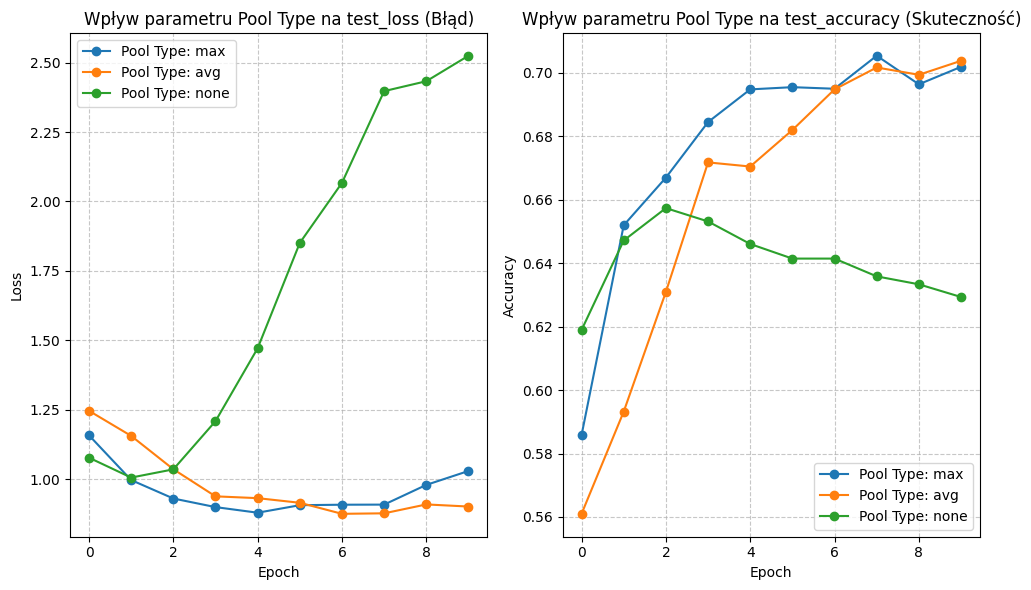

,Final Test Loss,Final Test Accuracy,Best Test Accuracy
Pool Type,,,
max,1.029776,0.7018,0.7053
avg,0.901780,0.7037,0.7037
none,2.524541,0.6293,0.6573


In [16]:
plot_experiment_series_reults(results_pool_type, 'Pool Type')
generate_results_table(results_pool_type, 'Pool Type')

### Wnioski z Serii IV: wpływ pooling

1. **`MaxPool2d` (niebieska krzywa - najniższy błąd):** Proces optymalizacji przebiega tutaj najszybciej, a model osiąga najniższe globalne minimum błędu na zbiorze testowym w okolicach 4. epoki. Ponieważ Max Pooling zachowuje wyłącznie najsilniejsze aktywacje (wyostrzając kluczowe cechy obiektów, takie jak krawędzie czy tekstury), optymalizator ma ułatwione zadanie. Należy jednak zauważyć, że ta agresywna ekstrakcja cech prowadzi do najgwałtowniejszego overfittingu w późniejszych epokach.
2. **`AvgPool2d` (pomarańczowa krzywa - wyższy błąd):** Krzywa opada zauważalnie wolniej i odbija się od wyższego pułapu błędu. Operacja uśredniania mapy cech zadziałała jak rozmycie. Zatracenie ostrości detali sprawiło, że optymalizator miał trudności ze zminimalizowaniem błędu, co bezpośrednio dowodzi, że dla zbioru CIFAR-10 ostre, wyraźne cechy są ważniejsze niż uśrednione tło.
3. **`Brak poolingu / none` (zielona krzywa - najwyższy błąd):** Krzywa błędu utrzymuje się na najwyższym poziomie i opada bardzo opornie. Jest to klasyczny objaw "klątwy wymiarowości". Brak redukcji map cech z 32x32 pikseli wygenerował tak gigantyczną przestrzeń parametrów w warstwie w pełni połączonej, że optymalizator gubił się w szumie informacyjnym, drastycznie spowalniając proces uczenia.

**Podsumowanie:** Analiza ostatecznie utwierdza w przekonaniu, że `MaxPool2d` to najbardziej optymalna architektura dla tego problemu. Aby zapobiec zaobserwowanemu na niebieskiej krzywej gwałtownemu przeuczeniu po 4. epoce, zalecanym krokiem byłoby zastosowanie techniki Early Stopping w momencie osiągnięcia minimum błędu.

## 6. Budowa najlepszego modelu oraz metryki
Dzięki wykonanym eksperymentom możemy zbudować model z optymalnie dobranymi hiperparametrami
* `learning_rate`: 0.001
* `batch_size`: 64
* `kernel_size`: 3
* `pool_type`: max

Model przejdzie przez 5 epok ponieważ z wcześniejszych analiz wiemy już, że na późniejszych etapach dochodzi do zjawiska `overfittingu` i model uczy się danych na pamięć.

Dla wytrenowanego modelu wygenerowany zostanie `raport klasyfikacji` z najważniejszymi metrykami oraz `macierz pomyłek` czyli świetna wizualizacja obrazująca gdzie model popełnił najwięcej błędów (które klasy sprawiają największe problemy, a które odróżnia prawie idalnie)

Dodatkowo na koniec pokazane zostanie parę przykładów źle dobranych klas do obrazów.

Files already downloaded and verified


c:\Coding\Uni\sem_II\PMiNA\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Epoch [1/5] Train Loss: 1.3816, Train Acc: 0.5101 Test Loss: 1.1385, Test Acc: 0.5937
Epoch [2/5] Train Loss: 1.0395, Train Acc: 0.6352 Test Loss: 1.0181, Test Acc: 0.6430
Epoch [3/5] Train Loss: 0.9014, Train Acc: 0.6824 Test Loss: 0.9627, Test Acc: 0.6631
Epoch [4/5] Train Loss: 0.8056, Train Acc: 0.7190 Test Loss: 0.9059, Test Acc: 0.6849
Epoch [5/5] Train Loss: 0.7257, Train Acc: 0.7465 Test Loss: 0.8777, Test Acc: 0.6955
RAPORT KLASYFIKACJI
              precision    recall  f1-score   support

       plain       0.72      0.76      0.74      1000
         car       0.83      0.77      0.80      1000
        bird       0.58      0.57      0.57      1000
         cat       0.54      0.45      0.49      1000
        deer       0.61      0.68      0.64      1000
         dog       0.60      0.59      0.60      1000
        frog       0.78      0.77      0.77      1000
       horse       0.71      0.77      0.74      1000
        ship       0.81  

<Figure size 1000x800 with 0 Axes>

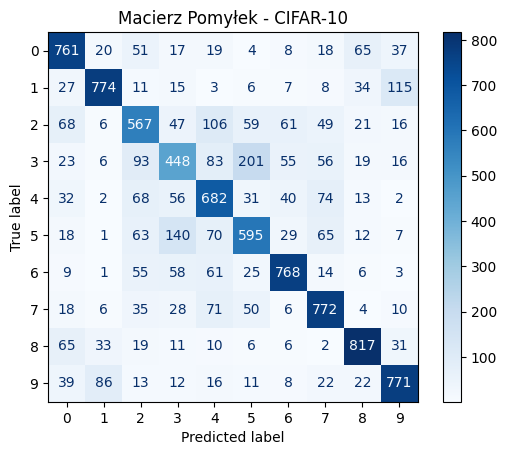

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.656061..2.110384].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5132424..1.845993].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.656061..1.3213184].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4496627..1.9320949].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8353425..2.0137537].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9641825..0

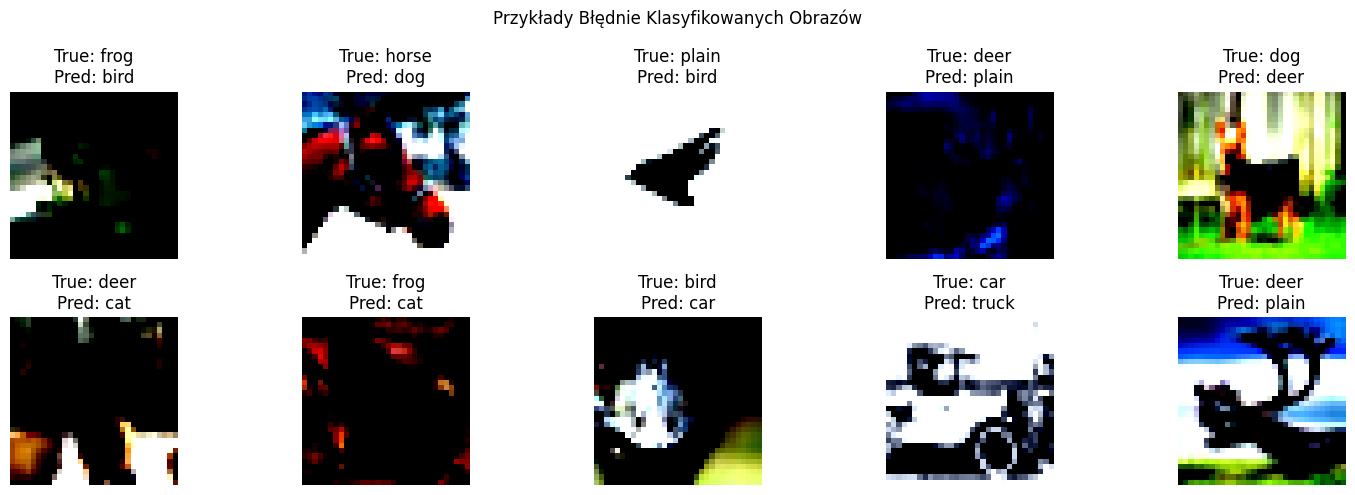

In [17]:
from visualization import metrics, show_misclassified_images

_, _, train_loader, test_loader = dataloaders(64)

best_model = ConvNet(kernel_size=3, pool_type='max')
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(best_model.parameters(), lr=0.001)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

history = train_model(best_model, train_loader, test_loader, criterion, optimizer, num_epochs=5, device=device)

metrics(best_model, test_loader, device, classes)
show_misclassified_images(best_model, test_loader, device, classes)

## 7. Podsumowanie Projektu

W ramach niniejszego zadania zaprojektowano, zaimplementowano oraz dogłębnie przetestowano od podstaw konwolucyjną sieć neuronową (CNN) przeznaczoną do klasyfikacji obrazów ze zbioru CIFAR-10. Proces budowy modelu oparto wyłącznie na surowych komponentach biblioteki PyTorch, bez wykorzystania gotowych, pretrenowanych architektur.

**Najważniejsze wnioski płynące z przeprowadzonych eksperymentów:**

1. **Wybór optymalnej architektury:** Zbudowana sieć udowadnia, że dla obrazów o bardzo niskiej rozdzielczości (32x32px) najlepiej sprawdzają się małe filtry konwolucyjne (`Kernel Size = 3`) oraz agresywna, wyostrzająca detale redukcja wymiarowości (`MaxPool2d`).
2. **Dynamika uczenia (Hiperparametry):** Wykazano, że dobór parametrów uczenia to poszukiwanie kompromisu między stabilnością a czasem. Współczynnik uczenia (`Learning Rate = 0.001`) w połączeniu z rozmiarem paczki (`Batch Size = 64`) okazały się "złotym środkiem", gwarantującym stabilny spadek funkcji straty bez nadmiernego szumu informacyjnego.
3. **Wyzwanie Przeuczenia (Overfitting):** Kluczowym odkryciem projektu była identyfikacja momentu przeuczenia. Analiza krzywych `Test Loss` konsekwentnie pokazywała, że model zaczyna tracić zdolność generalizacji po około 4-5 epoce. Oznacza to, że ślepe trenowanie przez ustaloną z góry, dużą liczbę epok jest błędem, a w architekturach tego typu bezwzględnie należy stosować technikę *Early Stopping* lub wprowadzić mocniejszą regularyzację (np. warstwy *Dropout*).

**Błędy**
Mimo osiągnięcia satysfakcjonujących wyników (Accuracy rzędu 70%), analiza błędnie sklasyfikowanych obrazów ujawniła trudności sieci z rozróżnianiem obiektów o podobnej teksturze i tle np. kot vs pies, statek vs samolot. 